# Lichess

## Подготовка окружения

```bash
./tools/install.sh
source .venv/bin/activate
python tools/get_data.py
```

In [ ]:
import pandas as pd
import numpy  as np

import chess
import chess.pgn

from   matplotlib import pyplot as plt

## Подготовка данных

### Рассмотрим какую-нибудь игру

In [71]:
def get_game(path: str, index: int) -> str:
    with open(path) as f:
        for _ in range(index):
            chess.pgn.skip_game(f)
        return chess.pgn.read_game(f)

In [72]:
print(get_game("data.pgn", 0))

[Event "rated blitz game"]
[Site "https://lichess.org/Lnhx4IvX"]
[Date "2026.04.29"]
[Round "-"]
[White "qorovin"]
[Black "crazyhandrick"]
[Result "0-1"]
[GameId "Lnhx4IvX"]
[UTCDate "2026.04.29"]
[UTCTime "12:58:46"]
[WhiteElo "1309"]
[BlackElo "1297"]
[WhiteRatingDiff "-6"]
[BlackRatingDiff "+6"]
[Variant "Standard"]
[TimeControl "300+3"]
[ECO "C44"]
[Opening "Ponziani Opening"]
[Termination "Time forfeit"]

1. e4 { [%clk 0:05:00] } 1... e5 { [%clk 0:05:00] } 2. Nf3 { [%clk 0:05:02] } 2... Nc6 { [%clk 0:05:00] } 3. c3 { [%clk 0:05:05] } 3... d6 { [%clk 0:05:01] } 4. d4 { [%clk 0:05:00] } 4... Bg4 { [%clk 0:05:02] } 5. d5 { [%clk 0:04:59] } 5... Bxf3 { [%clk 0:05:04] } 6. Qxf3 { [%clk 0:04:57] } 6... Nce7 { [%clk 0:05:00] } 7. Bb5+ { [%clk 0:04:54] } 7... c6 { [%clk 0:05:01] } 8. dxc6 { [%clk 0:04:50] } 8... bxc6 { [%clk 0:05:02] } 9. Bc4 { [%clk 0:04:46] } 9... Nf6 { [%clk 0:05:00] } 10. Bg5 { [%clk 0:04:36] } 10... Ng6 { [%clk 0:04:58] } 11. Bxf6 { [%clk 0:04:30] } 11... gxf6 { [%cl

### Что поменять

| Признаки                | Изменения                                            |
|-------------------------|----------------------------------------------------- |
| `Event`                 | Не учитывать (гарантируется `rated blitz game`)      |
| `Site`                  | Не учитывать                                         |
| `Date`                  | Не учитывать (более надежно – получить из `UTCDate`) |
| `Round`                 | Не учитывать (гарантируется `-`)                     |
| `White` + `Black`       | -> Бинарный признак `Color` (мои фигуры: White == 1) |
| `Result`                | -> One-hot encoding: `Win` + `Draw` + `Loss`         |
| `GameId`                | Не учитывать                                         |
| `UTCDate` + `UTCTime`   | -> `Date` (`0..1`) + `Time` (`0..23` по Москве)      |
| `WhiteElo` + `BlackElo` | -> `MyRate` + `OppRate` (рейтинги: мой и соперника)  |
| `W.R.Diff` + `B.R.Diff` | -> `MyRateDiff` + `OppRateDiff`                      |
| `Variant`               | -> Экземпляры только со значением `Standard`         |
| `TimeControl`           | Не учитывать (гарантируется `300+3`)                 |
| `ECO`                   | Без изменений                                        |
| `Opening`               | Без изменений                                        |
| `Termination`           | Без изменений                                        |
| `Запись ходов`          | -> `[ {ply, san, clr, rem_sec, mv_sec} ... ]`        |

`qorovin` – мой никнейм

### Получить датасет

In [73]:
from datetime import datetime, timezone, timedelta

In [74]:
NICK      = "qorovin"
SEC_INIT  = 300
SEC_INCR  = 3
MSC_TZ    = timezone(timedelta(hours=3))

In [75]:
import re

# [%clk H:MM:SS]
def parse_clock(comment):
    m = re.search(r'\[%clk (\d+):(\d+):(\d+)\]', comment)
    if m:
        h, mn, s = int(m.group(1)), int(m.group(2)), int(m.group(3))
        return h * 3600 + mn * 60 + s
    return None

In [76]:
# think_time = clock_before − clock_after + 3
def parse_moves(game):

    moves      = []
    last_clock = {chess.WHITE: SEC_INIT, chess.BLACK: SEC_INIT}
    node       = game
    
    while node.variations:
        node  = node.variations[0]
        mover = node.parent.board().turn
        clk   = parse_clock(node.comment)
        think = last_clock[mover] - clk + SEC_INCR if clk is not None else None
        moves.append({
            "ply":      node.ply(),
            "san":      node.san(),
            "clr":      "w" if mover == chess.WHITE else "b",
            "rem_sec":  clk,
            "mv_sec":   think,
        })
        if clk is not None:
            last_clock[mover] = clk
    return moves

In [77]:
rows = []

with open("data.pgn") as f:
    while True:
        game = chess.pgn.read_game(f)
        if game is None:
            break

        h = game.headers

        if h.get("Variant", "Standard") != "Standard":
            continue

        is_white = (h["White"] == NICK)

        result = h["Result"]
        if result == "1/2-1/2":
            win, draw, loss = 0, 1, 0
        elif (result == "1-0") == is_white:
            win, draw, loss = 1, 0, 0
        else:
            win, draw, loss = 0, 0, 1

        utc_dt = datetime.strptime(f"{h['UTCDate']} {h['UTCTime']}", "%Y.%m.%d %H:%M:%S")
        msc_dt = utc_dt.replace(tzinfo=timezone.utc).astimezone(MSC_TZ)
        hour   = round(msc_dt.hour + msc_dt.minute / 60) % 24

        if is_white:
            my_elo, opp_elo   = int(h["WhiteElo"]),        int(h["BlackElo"])
            my_diff, opp_diff = int(h["WhiteRatingDiff"]), int(h["BlackRatingDiff"])
        else:
            my_elo, opp_elo   = int(h["BlackElo"]),        int(h["WhiteElo"])
            my_diff, opp_diff = int(h["BlackRatingDiff"]), int(h["WhiteRatingDiff"])

        rows.append({
            "Color":       int(is_white),
            "Win":         win,
            "Draw":        draw,
            "Loss":        loss,
            "Date":        msc_dt.date(),
            "Time":        hour,
            "MyRate":      my_elo,
            "OppRate":     opp_elo,
            "MyRateDiff":  my_diff,
            "OppRateDiff": opp_diff,
            "ECO":         h.get("ECO", ""),
            "Opening":     h.get("Opening", ""),
            "Termination": h.get("Termination", ""),
            "__Moves":     parse_moves(game),
        })

df = pd.DataFrame(rows)

# Date: кол-во дней от первой партии → min-max [0, 1]
dates      = pd.to_datetime(df["Date"])
days       = (dates - dates.min()).dt.days
df["Date"] = days / days.max()

df.shape

(2052, 14)

In [78]:
df.head(2)

,Color,Win,Draw,Loss,Date,Time,MyRate,OppRate,MyRateDiff,OppRateDiff,ECO,Opening,Termination,__Moves
0,1,0,0,1,1.00000,16,1309,1297,-6,6,C44,Ponziani Opening,Time forfeit,"[{'ply': 1, 'san': 'e4', 'clr': 'w', 'rem_sec'..."
1,0,0,1,0,0.99887,20,1309,1322,0,0,C42,Petrov's Defense: Italian Variation,Normal,"[{'ply': 1, 'san': 'e4', 'clr': 'w', 'rem_sec'..."


In [79]:
df.tail(2)

,Color,Win,Draw,Loss,Date,Time,MyRate,OppRate,MyRateDiff,OppRateDiff,ECO,Opening,Termination,__Moves
2050,1,0,0,1,0.030508,17,719,735,-6,10,C42,Petrov's Defense: Three Knights Game,Normal,"[{'ply': 1, 'san': 'e4', 'clr': 'w', 'rem_sec'..."
2051,0,0,0,1,0.000000,22,920,941,-98,5,A00,Polish Opening: Symmetrical Variation,Normal,"[{'ply': 1, 'san': 'b4', 'clr': 'w', 'rem_sec'..."


## EDA

In [80]:
numeric_cols = ["MyRate", "OppRate", "MyRateDiff", "OppRateDiff"]
display(df[numeric_cols].describe().round(1))

,MyRate,OppRate,MyRateDiff,OppRateDiff
count,2052.0,2052.0,2052.0,2052.0
mean,1136.0,1136.9,0.1,-1.7
std,77.5,92.7,6.2,27.0
min,713.0,735.0,-98.0,-660.0
25%,1092.0,1077.0,-6.0,-6.0
50%,1151.0,1145.0,1.0,-1.0
75%,1187.0,1199.0,6.0,6.0
max,1328.0,1500.0,13.0,163.0


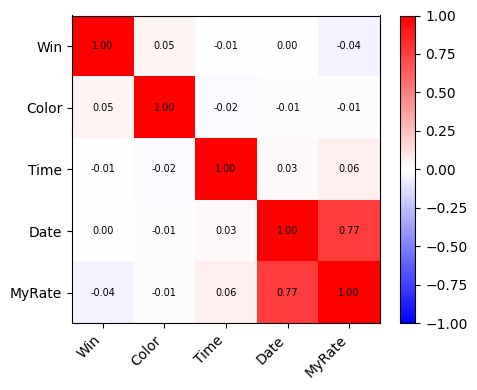

In [81]:
corr_cols = ["Win", "Color", "Time", "Date", "MyRate"]
corr      = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="bwr")
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [82]:
WCOL = "#4caf50"; DCOL = "#9e9e9e"; LCOL = "#f44336"

### Доля побед

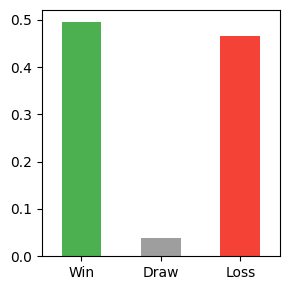

In [83]:
rates = df[["Win", "Draw", "Loss"]].mean()

fig, ax = plt.subplots(figsize=(3, 3))
rates.plot.bar(ax=ax, color=[WCOL, DCOL, LCOL])

plt.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Какие дебюты приносят мне победы?

#### Winrate vs частота дебюта

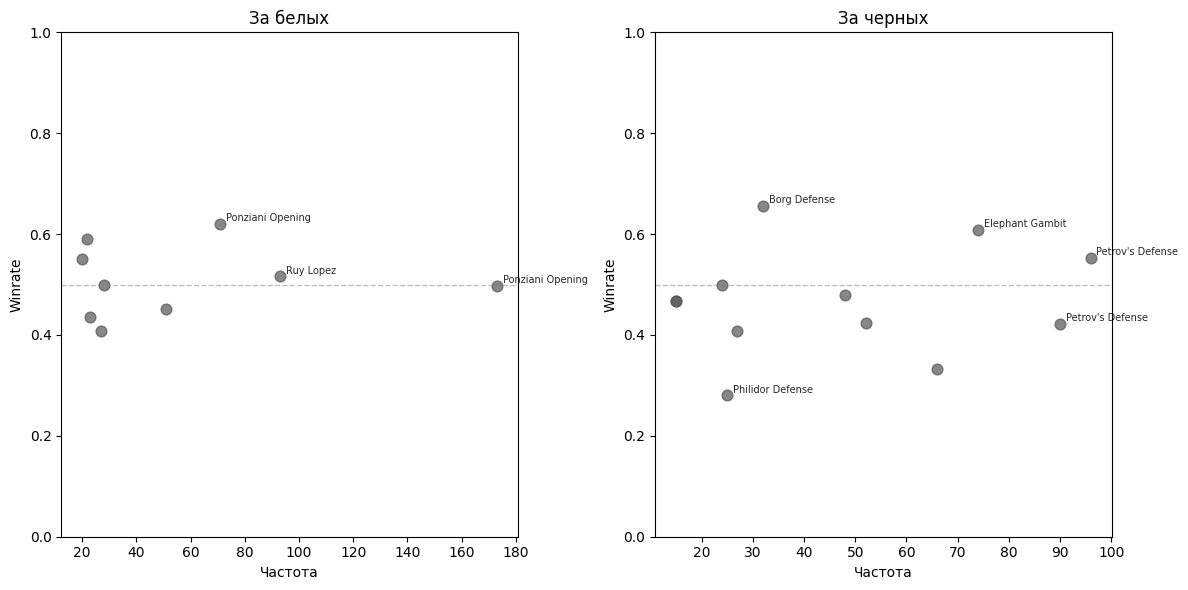

In [84]:
def opening_scatter_data(color, min_games):
    grp = df[df["Color"] == color].groupby("Opening")[["Win", "Draw", "Loss"]].sum()
    grp["Total"]   = grp.sum(axis=1)
    grp            = grp[grp["Total"] >= min_games]
    grp["WinRate"] = grp["Win"] / grp["Total"]
    return grp

white_s = opening_scatter_data(1, 20)
black_s = opening_scatter_data(0, 15)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, grp, title in [(axes[0], white_s, "За белых"), (axes[1], black_s, "За черных")]:
    ax.scatter(grp["Total"], grp["WinRate"], alpha=0.7, s=60, color="#555")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_xlabel("Частота")
    ax.set_ylabel("Winrate")
    ax.set_title(title)
    ax.set_ylim(0, 1)

    freq_thresh = grp["Total"].quantile(0.75)
    wr_mean     = grp["WinRate"].mean()
    wr_std      = grp["WinRate"].std()

    for opening, row in grp.iterrows():
        if row["Total"] >= freq_thresh or abs(row["WinRate"] - wr_mean) > 1.5 * wr_std:
            label = opening.split(":")[0][:28]
            ax.annotate(label, (row["Total"], row["WinRate"]),
                        fontsize=7, alpha=0.85, xytext=(4, 2), textcoords="offset points")

plt.tight_layout()
plt.show()

#### Гистограммы частот `Opening`

In [85]:
def opening_wdl(color):
    grp = df[df["Color"] == color].groupby("Opening")[["Win", "Draw", "Loss"]].sum()
    counts = grp.sum(axis=1).sort_values(ascending=False)
    grp = grp.loc[counts[counts >= counts.iloc[0] * 0.15].index]
    return grp

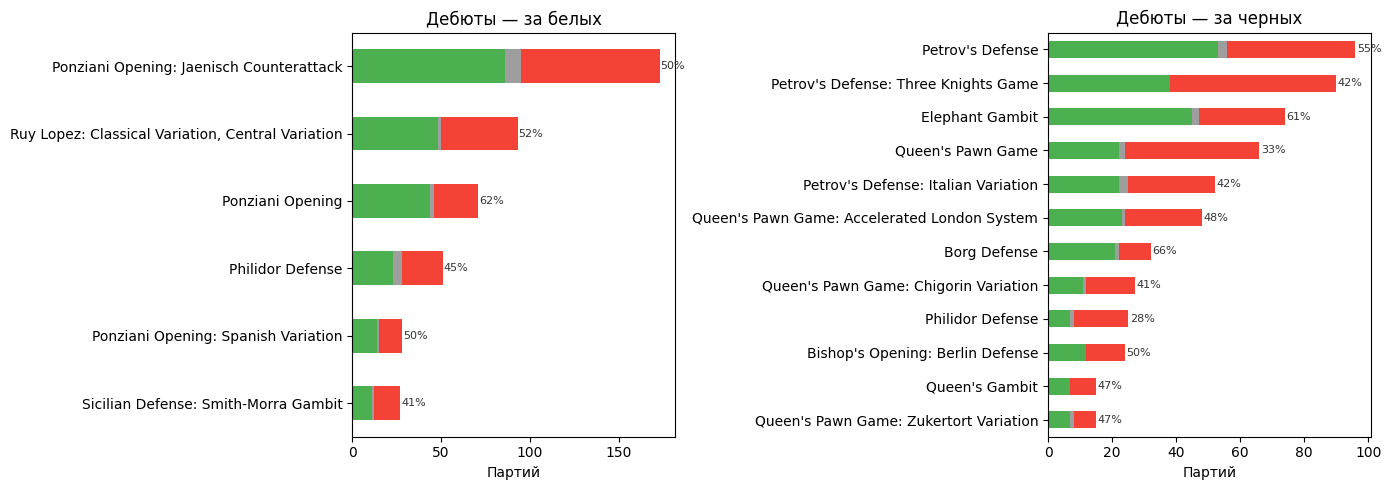

In [86]:
white_grp = opening_wdl(1)
black_grp = opening_wdl(0)

wdl_colors = [WCOL, DCOL, LCOL]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

white_grp[["Win", "Draw", "Loss"]].plot.barh(ax=axes[0], color=wdl_colors, stacked=True, legend=False)
axes[0].set_title("Дебюты — за белых")
axes[0].set_xlabel("Партий")
axes[0].set_ylabel("")
axes[0].invert_yaxis()
for i, (_, row) in enumerate(white_grp.iterrows()):
    total = row[["Win", "Draw", "Loss"]].sum()
    axes[0].text(total + 0.5, i, f"{row['Win'] / total:.0%}", va="center", fontsize=8, color="#333")

black_grp[["Win", "Draw", "Loss"]].plot.barh(ax=axes[1], color=wdl_colors, stacked=True, legend=False)
axes[1].set_title("Дебюты — за черных")
axes[1].set_xlabel("Партий")
axes[1].set_ylabel("")
axes[1].invert_yaxis()
for i, (_, row) in enumerate(black_grp.iterrows()):
    total = row[["Win", "Draw", "Loss"]].sum()
    axes[1].text(total + 0.5, i, f"{row['Win'] / total:.0%}", va="center", fontsize=8, color="#333")

plt.tight_layout()
plt.show()

In [87]:
import chess.svg
from IPython.display import SVG
from typing import Literal

def display_board(color: Literal["w", "b"], san: list[str]):
    board = chess.Board()
    for s in san:
        board.push_san(s)
    orient = chess.WHITE if color == "w" else chess.BLACK
    return SVG(chess.svg.board(board, size=250, orientation=orient))

#### Ponziani Opening (62%)

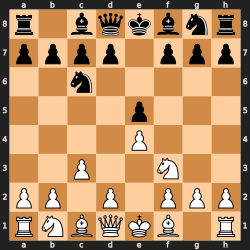

In [88]:
Ponziani_Opening = ["e4", "e5", "Nf3", "Nc6", "c3"]
display_board("w", Ponziani_Opening)

#### Ponziani Opening: Jaenish Counterattack (50%)
Правильный ход соперника уравнивает шансы.

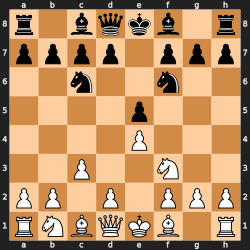

In [89]:
display_board("w", Ponziani_Opening + ["Nf6"])

#### Queen's Pawn Game (33%)
Я не умею играть против этого.

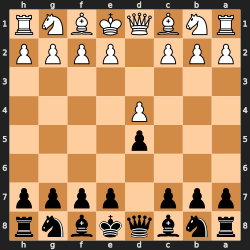

In [90]:
display_board("b", ["d4", "d5"])

#### Borg Defence (66%)

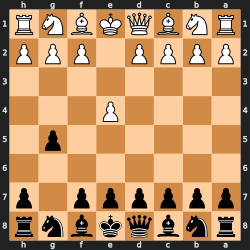

In [91]:
display_board("b", ["e4", "g5"])

#### Elephant Gambit (61%)

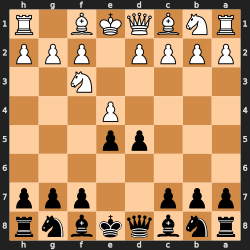

In [92]:
display_board("b", ["e4", "e5", "Nf3", "d5"])

Может быть связан с тем, что в прошлом я играл с более слабыми соперниками.  
Например, *Borg Defence* и *Elephant Gambit* я любил играть достаточно давно в качестве развлечения.  

В то же время эти дебюты могли вызывать озадаченность соперника своей редкостью.  

Но при этом эта озадаченность может кореллировать с неопытностью:  
там, где более опытные игроки полагаются на универсальные паттерны, новички пасуют.

- Стоит придумать **метрику значимости победы**.  
- Она бы позволила учесть разные обстоятельства при оценке успешности дебюта.  
- Логично использовать рейтинг соперника.  

#### -> Elo-ожидание

$P_{\text{expected}} = \frac{1}{1 + 10^{(\text{OppRate} - \text{MyRate})\,/\,400}}$

$\text{significance}(win)  = 1 - P_{\text{expected}}$  
$\text{significance}(draw) = 0.5 - P_{\text{expected}}$  

Сильный соперник -> неожиданнее победа, выше вес.  


Значимость дебюта:  

$\text{weighted\_score} = \dfrac{\sum \text{significance}}{n\_\text{games}}$

## Notes


### Сложно

Lichess использует систему **Glicko-2** (Glickman, 1995).


### Что система хранит о каждом игроке

| Обозначение | Название | Смысл |
|---|---|---|
| $r$ | Рейтинг | Число, которое ты видишь на Lichess (например, 1322) |
| $RD$ | Rating Deviation, отклонение | Насколько система *уверена* в $r$. Чем меньше — тем точнее оценка. <br>Новые игроки: $RD \approx 350$. Опытные: $RD \approx 50$. |
| $\sigma$ | Волатильность | Мера *нестабильности* игрока. Если результаты скачут — $\sigma$ растёт. |

> После долгого перерыва $RD$ автоматически увеличивается: система "забывает" уверенность в твоём рейтинге.


### Шаг 0 — перевод во внутреннюю шкалу

Glicko-2 работает не с привычными числами, а с нормированными:

$$\mu = \frac{r - 1500}{173.7178}, \qquad \phi = \frac{RD}{173.7178}$$

> Просто линейный пересчёт. 1500 — исторический ноль системы, 173.7178 — нормировочная константа.


### Шаг 1 — сколько очков ожидает система?

Для каждой партии $j$ против соперника $(\mu_j, \phi_j)$ вычисляется ожидаемый результат $E_j$ — что-то вроде вероятности победы:

$$g(\phi_j) = \frac{1}{\sqrt{1 + \dfrac{3\,\phi_j^2}{\pi^2}}}$$

$$E_j \;=\; \frac{1}{1 + e^{-g(\phi_j)\,(\mu - \mu_j)}}$$

| Переменная | Смысл |
|---|---|
| $g(\phi_j)$ | Понижающий коэффициент: если у соперника большое $RD$ (мы не уверены в его рейтинге), вес этой партии уменьшается |
| $E_j \in (0, 1)$ | Ожидаемый результат. $E_j > 0.5$ — ты фаворит, $E_j < 0.5$ — аутсайдер |
| $s_j \in \{0,\, 0.5,\, 1\}$ | Фактический результат: поражение / ничья / победа |

> Ключевая величина — разность $s_j - E_j$: насколько ты удивил систему.  
> Победил фаворита — большой плюс. Проиграл аутсайдеру — большой минус.


### Шаг 2 — оценочная дисперсия $v$

$$v = \left[\,\sum_j\, g(\phi_j)^2 \cdot E_j \cdot (1 - E_j)\right]^{-1}$$

> $v$ — "сколько информации" дали сыгранные партии. Чем уверенней соперник (маленький $\phi_j$) и чем равнее матч ($E_j \approx 0.5$), тем меньше $v$ и тем сильнее система обновит оценку.


### Шаг 3 — обновление волатильности $\sigma \to \sigma'$

Это самый сложный шаг. Система ищет корень уравнения

$$f(x) = \frac{e^x\!\left(\Delta^2 - \phi^2 - v - e^x\right)}{2\left(\phi^2 + v + e^x\right)^2} - \frac{x - \ln \sigma^2}{\tau^2} = 0$$

где

$$\Delta = v \cdot \sum_j g(\phi_j)\,(s_j - E_j)$$

| Переменная | Смысл |
|---|---|
| $\Delta$ | Суммарное "удивление": насколько реальные результаты отличались от ожидаемых |
| $\tau$ | Системная константа (Lichess: $\tau \approx 0.75$). Ограничивает, как быстро может меняться $\sigma$ |

Корень $x^*$ находится итеративным алгоритмом (Illinois), затем:

$$\sigma' = e^{\,x^*/2}$$

> Если ты играл нестабильно (неожиданно хорошо или плохо) — $\sigma'$ растёт.  
> Если результаты предсказуемы — $\sigma'$ чуть уменьшается.


### Шаг 4 — обновление отклонения $RD \to RD'$

Сначала $\phi$ немного раздувается с учётом волатильности:

$$\phi^* = \sqrt{\phi^2 + \sigma'^2}$$

> Именно здесь $\sigma'$ наконец используется. Чем выше волатильность — тем больше $\phi^*$, то есть тем менее уверена система в рейтинге после партии.

Затем уверенность повышается за счёт сыгранных партий:

$$\phi' = \frac{1}{\sqrt{\,1/\phi^{*2} + 1/v\,}}$$

> Много партий с уверенными соперниками → маленькое $v$ → маленькое $\phi'$ → $RD$ снижается.


### Шаг 5 — новый рейтинг

$$\mu' = \mu + {\phi'}^2 \cdot \sum_j g(\phi_j)\,(s_j - E_j)$$

$$\boxed{\;\Delta r \;=\; r' - r \;=\; 173.7178 \cdot (\mu' - \mu)\;}$$

> $\phi'^2$ — множитель чувствительности. Если $RD$ велико (система неуверена) — рейтинг меняется сильнее. Если мал — слабее.  
> Именно поэтому у новых игроков рейтинг скачет на ±50, а у опытных — на ±5.


### Итоговая картина зависимостей

$$\sigma \;\xrightarrow{\text{Illinois}}\; \sigma' \;\to\; \phi^* \;\to\; \phi' \;\to\; \Delta r$$

Волатильность $\sigma$ влияет на $\Delta r$ косвенно: через $\phi^*$, а затем через $\phi'$.

## ML

### Задача

Предсказывать `Win / Draw / Loss` по признакам:

- Разница рейтингов  
  `MyRate - OppRate`  

- Разность оставшегося времени  
  `__Moves[rem_sec]`  
  для данного номера хода  
  `__Moves[ply]`


-> При каком запасе времени к ходу N я обычно выигрываю?

### Todo от предподавателя

- `Boosting`
- Время: добавить признаки из `prophet` (?) Я так понял, это относится к EDA для глобального времени.
- Если основной признак, влияющий на выигрыш – время (?) – проверить `ema`, `arima` и подобное как бэйслайны.

# Новый ipynb

Теперь, рассмотрев данные, я сформулировал задачу конкретно, и хотел бы пройти этапы ML заново – конкретно под эту задачу.